# Inspect Harp `.bin` log

Parses each message by its payload-type byte, groups by register address, plots one subplot per data column.

In [11]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = False

BIN_PATH = Path(
    r"../Logs/sub-ALGERNON/ses-1_date-2026-05-05T14-09-18/HarpLog_44/HarpLog_442026-05-05T15_09_18.bin"
)

In [12]:
HAS_TIMESTAMP = 0x10

_BASE_DTYPE = {
    0x01: (np.uint8, 1),
    0x02: (np.uint16, 2),
    0x04: (np.uint32, 4),
    0x08: (np.uint64, 8),
    0x81: (np.int8, 1),
    0x82: (np.int16, 2),
    0x84: (np.int32, 4),
    0x88: (np.int64, 8),
    0x44: (np.float32, 4),
    0x48: (np.float64, 8),
}


def read_harp_bin(path: Path) -> dict[int, pd.DataFrame]:
    """Return {register_address: DataFrame(time, Col1, Col2, ...)}."""
    raw = np.fromfile(path, dtype=np.uint8)
    by_addr: dict[int, list] = defaultdict(list)

    i, n = 0, raw.size
    while i < n:
        length = int(raw[i + 1])
        total = length + 2
        msg = raw[i : i + total]
        addr = int(msg[2])
        ptype = int(msg[4])
        has_ts = bool(ptype & HAS_TIMESTAMP)

        base = ptype & ~HAS_TIMESTAMP
        if base not in _BASE_DTYPE:
            raise ValueError(f"unknown Harp payload type 0x{ptype:02x}")
        dtype, elem_size = _BASE_DTYPE[base]

        ts_bytes = 6 if has_ts else 0
        payload = msg[5 + ts_bytes : -1]  # strip checksum
        n_elems = payload.size // elem_size
        values = payload[: n_elems * elem_size].view(dtype)

        if has_ts:
            sec = msg[5:9].view(np.uint32)[0]
            us = msg[9:11].view(np.uint16)[0]
            t = float(sec) + float(us) * 32e-6
        else:
            t = np.nan

        by_addr[addr].append((t, values))
        i += total

    out: dict[int, pd.DataFrame] = {}
    for addr, rows in by_addr.items():
        times = np.array([r[0] for r in rows], dtype=np.float64)
        widths = {len(r[1]) for r in rows}
        if len(widths) == 1:
            data = np.stack([r[1] for r in rows])
            cols = [f"Col{j + 1}" for j in range(data.shape[1])] if data.ndim == 2 else ["Col1"]
            df = pd.DataFrame(data, columns=cols)
        else:
            df = pd.DataFrame({"Col1": [r[1] for r in rows]})  # ragged
        df.insert(0, "time", times)
        out[addr] = df
    return out

In [13]:
registers = read_harp_bin(BIN_PATH)
print(f"{BIN_PATH.name}: {sum(len(df) for df in registers.values())} messages across {len(registers)} register(s)")
for addr, df in registers.items():
    dur = df['time'].iloc[-1] - df['time'].iloc[0] if len(df) > 1 else 0.0
    cols = ', '.join(c for c in df.columns if c != 'time')
    print(f"  addr {addr:3d}: {len(df):6d} msgs  {dur:7.3f} s  cols=[{cols}]")

HarpLog_442026-05-05T15_09_18.bin: 43950 messages across 1 register(s)
  addr  44:  43950 msgs   43.949 s  cols=[Col1, Col2, Col3]


In [14]:
for addr, df in registers.items():
    print(f"--- register {addr} ---")
    display(df.describe())

--- register 44 ---


,time,Col1,Col2,Col3
count,4.395000e+04,43950.000000,43950.000000,43950.0
mean,3.860835e+09,10.614221,5445.044232,0.0
std,1.268742e+01,1.047161,15869.871109,0.0
min,3.860835e+09,6.000000,-32764.000000,0.0
25%,3.860835e+09,10.000000,0.000000,0.0
50%,3.860835e+09,11.000000,8482.000000,0.0
75%,3.860835e+09,11.000000,16077.000000,0.0
max,3.860835e+09,15.000000,32766.000000,0.0


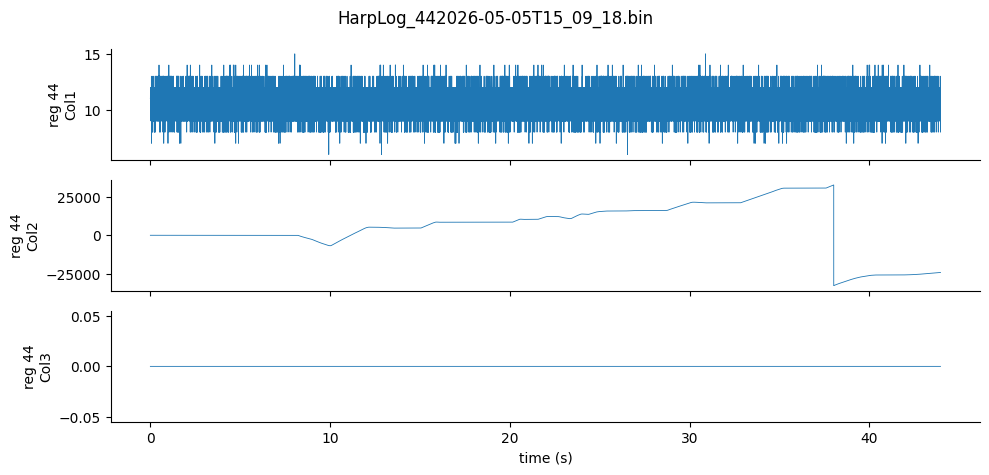

In [15]:
panels = [(addr, c) for addr, df in registers.items() for c in df.columns if c != "time"]
fig, axes = plt.subplots(len(panels), 1, sharex=True, figsize=(10, 1.6 * len(panels)))
if len(panels) == 1:
    axes = [axes]

t0 = min(df["time"].iloc[0] for df in registers.values() if len(df))
for ax, (addr, col) in zip(axes, panels):
    df = registers[addr]
    ax.plot(df["time"] - t0, df[col], linewidth=0.6)
    ax.set_ylabel(f"reg {addr}\n{col}")
axes[-1].set_xlabel("time (s)")
fig.suptitle(BIN_PATH.name)
fig.tight_layout()
plt.show()